In [46]:
import numpy as np
import joblib
import pandas as pd
from skimage import measure
from skimage.measure import shannon_entropy
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

IMG_SIZE = (512, 256)  # до какого размера были сжаты изображения

In [2]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [3]:
for i in range(10):
    print(f"Размерность {i} элемента {X[i].shape}")

Размерность 0 элемента (59, 115)
Размерность 1 элемента (60, 179)
Размерность 2 элемента (61, 423)
Размерность 3 элемента (24, 37)
Размерность 4 элемента (58, 115)
Размерность 5 элемента (41, 268)
Размерность 6 элемента (40, 300)
Размерность 7 элемента (38, 93)
Размерность 8 элемента (28, 64)
Размерность 9 элемента (77, 75)


In [4]:
def extract_features(diff_image, top_left):
    """
    Извлекает признаки из diff-области.
    
    Parameters:
        diff_image: обрезанное diff-изображение
        top_left: кортеж (y, x) координат относительно исходного скриншота
    """
    features = {}
    
    h, w = diff_image.shape
    
    # 1. Геометрические признаки (bounding box)
    features['width'] = w
    features['height'] = h
    features['area_bbox'] = w * h
    features['aspect_ratio'] = w / h if h > 0 else 0
    features['relative_area'] = (w * h) / (IMG_SIZE[0] * IMG_SIZE[1])
    
    # 2. Позиционные признаки
    features['top_left_y'] = top_left[0]
    features['top_left_x'] = top_left[1]
    features['center_y_norm'] = (top_left[0] + h/2) / IMG_SIZE[1]
    features['center_x_norm'] = (top_left[1] + w/2) / IMG_SIZE[0]
    
    # 3. Признаки интенсивности
    features['mean_intensity'] = np.mean(diff_image)
    features['std_intensity'] = np.std(diff_image)
    features['max_intensity'] = np.max(diff_image)
    features['sum_intensity'] = np.sum(diff_image)
    features['nonzero_ratio'] = np.count_nonzero(diff_image) / diff_image.size
    
    # 4. Морфологические признаки (связные компоненты)
    binary = (diff_image > 0.01).astype(np.uint8)
    labeled = measure.label(binary, connectivity=2)
    regions = measure.regionprops(labeled)
    
    features['num_components'] = len(regions)
    
    if len(regions) > 0:
        areas = [r.area for r in regions]
        features['largest_component_area'] = max(areas)
        features['largest_component_ratio'] = max(areas) / (np.count_nonzero(binary) + 1)
        features['mean_component_area'] = np.mean(areas)
        features['std_component_area'] = np.std(areas) if len(areas) > 1 else 0
        
        # Характеристики крупнейшей компоненты
        largest_region = max(regions, key=lambda r: r.area)
        features['largest_compactness'] = (largest_region.perimeter ** 2) / (4 * np.pi * largest_region.area + 1)
        features['largest_eccentricity'] = largest_region.eccentricity
        features['largest_solidity'] = largest_region.solidity  # area / convex_area
        features['largest_extent'] = largest_region.extent  # area / bbox_area
        features['largest_orientation'] = largest_region.orientation
    else:
        features['largest_component_area'] = 0
        features['largest_component_ratio'] = 0
        features['mean_component_area'] = 0
        features['std_component_area'] = 0
        features['largest_compactness'] = 0
        features['largest_eccentricity'] = 0
        features['largest_solidity'] = 0
        features['largest_extent'] = 0
        features['largest_orientation'] = 0
    
    # 5. Текстурные признаки
    # Приводим к одному размеру для текстурного анализа
    resized = resize(diff_image, (32, 32), anti_aliasing=True)
    
    features['entropy'] = shannon_entropy(resized + 1e-10)
    
    # Статистики проекций
    row_proj = np.sum(resized, axis=1)
    col_proj = np.sum(resized, axis=0)
    features['std_row_projection'] = np.std(row_proj)
    features['std_col_projection'] = np.std(col_proj)
    features['max_row_projection'] = np.max(row_proj)
    features['max_col_projection'] = np.max(col_proj)
    
    return features


def create_feature_dataset(X_diff, X_coords):
    """
    Создает датафрейм с признаками для всех образцов.
    
    Parameters:
        X_diff: список обрезанных diff-изображений
        X_coords: список кортежей (y, x) верхнего левого угла
    """
    all_features = []
    
    for i, (diff_img, coords) in enumerate(zip(X_diff, X_coords)):
        features = extract_features(diff_img, coords)
        features['sample_id'] = i
        all_features.append(features)
    
    df = pd.DataFrame(all_features)
    return df

In [5]:
df_features = create_feature_dataset(X, X_coords)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (818, 30)
Количество признаков: 29

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_eccentricity  largest_solidity  largest_extent  \
0              0.470199   

In [16]:
# Создаём метки подтипов на основе индексов
subtype_labels = []
for i in range(len(df_features)):
    if i < 200:
        subtype_labels.append('disappeared')
    elif i < 250:
        subtype_labels.append('color_change')
    elif i < 400:
        subtype_labels.append('shift')
    elif i < 500:
        subtype_labels.append('dynamic')
    else:
        subtype_labels.append('banner')

subtype_labels = np.array(subtype_labels)

X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

# Проверяем распределение
print("Распределение подтипов в train:")
print(pd.Series(sub_train).value_counts(normalize=True))
print("\nРаспределение подтипов в test:")
print(pd.Series(sub_test).value_counts(normalize=True))

Распределение подтипов в train:
banner          0.388112
disappeared     0.244755
shift           0.183566
dynamic         0.122378
color_change    0.061189
Name: proportion, dtype: float64

Распределение подтипов в test:
banner          0.390244
disappeared     0.243902
shift           0.182927
dynamic         0.121951
color_change    0.060976
Name: proportion, dtype: float64


### Предварительные выводы
Подготовка данных почти завершена. Не делали нормализацию, так как для деревьев она не играет роли. Сначала посмотрим как они справятся.

Данные с датасетом в 2 раза меньше:
```
precision    recall  f1-score   support

           0       0.98      0.97      0.97        60
           1       0.97      0.98      0.98        60

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.168068
1                   height    0.114329
2                area_bbox    0.111024
18      std_component_area    0.080326
12           sum_intensity    0.078896
11           max_intensity    0.067726
0                    width    0.054544
15  largest_component_area    0.033148
8            center_x_norm    0.032370
24                 entropy    0.029890
```

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       126
           1       0.98      0.94      0.96       120

    accuracy                           0.96       246
   macro avg       0.96      0.96      0.96       246
weighted avg       0.96      0.96      0.96       246


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.155518
2                area_bbox    0.093344
1                   height    0.092793
0                    width    0.089547
15  largest_component_area    0.055263
12           sum_intensity    0.050038
7            center_y_norm    0.044786
18      std_component_area    0.042177
8            center_x_norm    0.038960
11           max_intensity    0.037527


In [18]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.00      0.00      0.00         0

    accuracy                           0.99        96
   macro avg       0.50      0.49      0.50        96
weighted avg       1.00      0.99      0.99        96


=== color_change ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        15

    accuracy                           0.93        15
   macro avg       0.50      0.47      0.48        15
weighted avg       1.00      0.93      0.97        15


=== disappeared ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98        60

    accuracy                           0.97        60
   macro avg       0.50      0.48      0.49        60
weighted avg   

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

Индексы с ошибками [358 387 143 313 465 226 142 690 280]


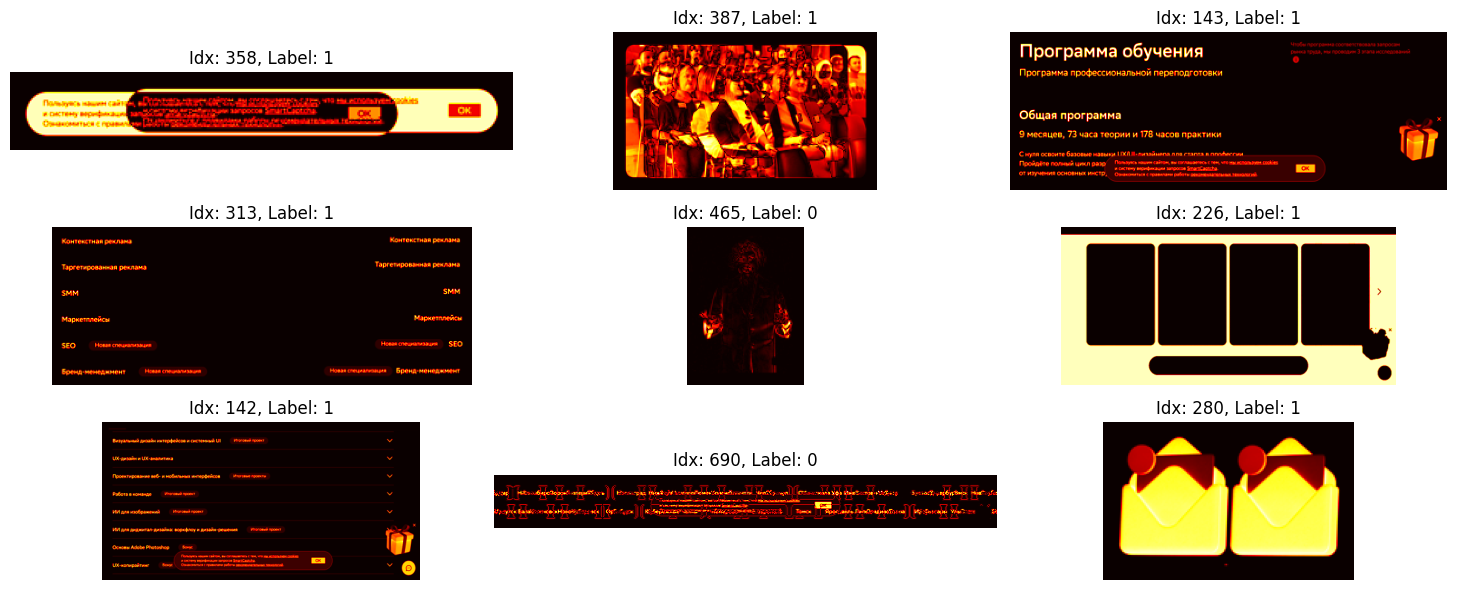

In [20]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(3, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

### Выводы

Идеальной классификации нет нигде.

226 и 465 соответственно color_change и dynamic про динамический элемент ничего не скажу, но вот изменение цвета явно пострадало из-за того, что я спеециально добавил пару элементов с исчезновением большой области.

143 и 142 disappeared логично упали. Я специально добавил исчезновение здоровенного блока элементов. Таких кейсов мало в обучающей выборке. Так что это больше показательный кейс. Легко исправится добавлением в обучение большего числа таких кейсов.

690 banner — даже лучше чем при меньшем датасете! Не ошиблась в старых! Но упала опять же на очень спорном кейсе!!! (РАЗОБРАТЬ!!!)

358, 387, 313 и 280 shift (сдвиг элемента) — recall 0.91(0.93 раньше) для класса 1 (4(1 раньше) пропущенных бага из 45). Это пропущенные дефект! Это плохо! Логично, я ещё не добавлял метод анализа зеркалирования.

Попробуем сделать анализ зеркальных элементов, то есть разделение diff по середине по оси Y и по оси X и проверку совпадают ли эти части. Если да, то это однозначно баг сдвига.

In [31]:
def compute_symmetry_score_enhanced(diff_images):
    """
    Делит diff-область пополам по вертикали и горизонтали,
    сравнивает половинки через среднюю абсолютную разницу.
    Возвращает минимальную разницу (0 = полная симметрия).
    Улучшенная версия с нормализацией и поиском симметрии с небольшим сдвигом
    """
    symmetry_score = []

    for diff_image in diff_images:
        h, w = diff_image.shape
        
        # Нормализация для устойчивости
        if diff_image.max() > 0:
            diff_norm = diff_image / diff_image.max()
        else:
            symmetry_score.append(0)
            continue
        
        best_score = float('inf')
        
        # Пробуем разные точки разделения для поиска наилучшей симметрии
        for offset in range(-2, 3):  # Небольшой сдвиг
            mid_w = (w // 2) + offset
            if mid_w <= 0 or mid_w >= w:
                continue
                
            left = diff_norm[:, :mid_w]
            right = np.fliplr(diff_norm[:, mid_w:2*mid_w]) if 2*mid_w <= w else np.fliplr(diff_norm[:, w-mid_w:])
            
            # Приводим к одному размеру
            min_w = min(left.shape[1], right.shape[1])
            if min_w > 0:
                vert_diff = np.mean(np.abs(left[:, :min_w] - right[:, :min_w]))
                best_score = min(best_score, vert_diff)
        
        symmetry_score.append(best_score)
    
    return symmetry_score

In [32]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [33]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (818, 31)
Количество признаков: 30

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_solidity  largest_extent  largest_orientation   entropy  \
0          0.6718

In [34]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       126
           1       0.98      0.96      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.115084
2                area_bbox    0.103133
1                   height    0.091765
12           sum_intensity    0.077006
15  largest_component_area    0.075525
0                    width    0.064349
8            center_x_norm    0.042767
11           max_intensity    0.039910
7            center_y_norm    0.032856
13           nonzero_ratio    0.028553


In [35]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.00      0.00      0.00         0

    accuracy                           0.99        96
   macro avg       0.50      0.49      0.50        96
weighted avg       1.00      0.99      0.99        96


=== color_change ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15


=== disappeared ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98        60

    accuracy                           0.97        60
   macro avg       0.50      0.48      0.49        60
weighted avg       1.00      0.97      0.98        60


=== dynamic =

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

Индексы с ошибками [358 387 143 313 465 142 690]


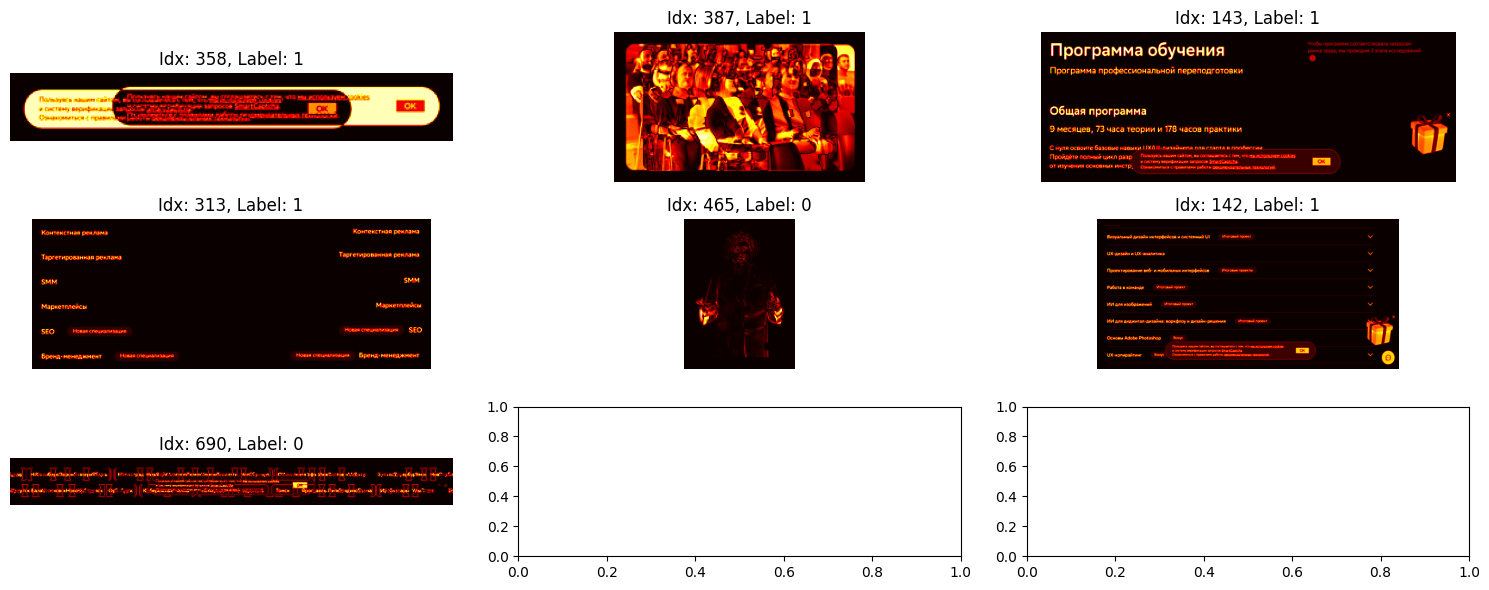

In [36]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(3, 3, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

### Выводы

#### Раньше:
Симметрия не помогла исключить баг. Данный признак и в том не попал, но оставим его для кучи, а то и так их не много. Попробуем повторяющиеся паттерны.

#### Сейчас:
-2 бага вообще-то! Правда один из них в цвете :) Ну и ладно.

In [37]:
def detect_duplicated_pattern(diff_images):
    """
    Ищет повторяющиеся вертикальные паттерны в diff-изображении.
    Возвращает score (0 = идеальное повторение, т.е. явный сдвиг)
    """
    duplicate_pattern_best_score = []
    duplicate_pattern_best_shift = []
    for diff_image in diff_images:
        h, w = diff_image.shape
        
        if h < 10 or w < 10:
            return 1.0
        
        best_score = 1.0
        best_shift = 0
        
        # Ищем повторяющиеся колонки/блоки
        # Пробуем разные сдвиги (половина ширины и другие)
        for shift_ratio in [0.5, 0.33, 0.25]:  # Проверяем разные соотношения
            shift = int(w * shift_ratio)
            if shift < 10:
                continue
                
            # Сравниваем левую часть с правой (со сдвигом)
            for start in range(0, w - shift, max(1, shift // 4)):
                left_block = diff_image[:, start:start + shift]
                right_block = diff_image[:, start + shift:start + 2*shift]
                
                if right_block.shape[1] >= shift * 0.8:
                    # Обрезаем до одинакового размера
                    min_w = min(left_block.shape[1], right_block.shape[1])
                    if min_w > 5:
                        # Нормализуем
                        left_norm = left_block[:, :min_w].astype(float)
                        right_norm = right_block[:, :min_w].astype(float)
                        
                        if left_norm.max() > 0:
                            left_norm /= left_norm.max()
                        if right_norm.max() > 0:
                            right_norm /= right_norm.max()
                        
                        similarity = np.mean(np.abs(left_norm - right_norm))
                        
                        if similarity < best_score:
                            best_score = similarity
                            best_shift = shift
        
        duplicate_pattern_best_score.append(best_score)
        duplicate_pattern_best_shift.append(best_shift)
    return duplicate_pattern_best_score, duplicate_pattern_best_shift

In [38]:
X = joblib.load('X_cropped_diff_images_2_increase_ds.joblib')
X_coords = joblib.load('X_coords_diff_images_2_increase_ds.joblib')
y = joblib.load('y_labels_2_increase_ds.joblib')

print(f"Загружено {len(X)} изображений")
print(f"Загружено {len(X_coords)} координат левого верхнегно угла")
print(f"Загружено {len(y)} лейблов")

Загружено 818 изображений
Загружено 818 координат левого верхнегно угла
Загружено 818 лейблов


In [39]:
df_features = create_feature_dataset(X, X_coords)
df_features['symmetry_score'] = compute_symmetry_score_enhanced(X)
duplicated_pattern = detect_duplicated_pattern(X)
df_features['duplicated_pattern_best_score'] = duplicated_pattern[0]
df_features['duplicated_pattern_best_shift'] = duplicated_pattern[1]

print(f"Размер датафрейма: {df_features.shape}")
print(f"Количество признаков: {df_features.shape[1] - 1}")
print("\nПервые 5 строк:")
print(df_features.head())
print("\nСтатистика по признакам:")
print(df_features.describe())

Размер датафрейма: (818, 33)
Количество признаков: 32

Первые 5 строк:
   width  height  area_bbox  aspect_ratio  relative_area  top_left_y  \
0    115      59       6785      1.949153       0.051765          33   
1    179      60      10740      2.983333       0.081940         162   
2    423      61      25803      6.934426       0.196861          99   
3     37      24        888      1.541667       0.006775         128   
4    115      58       6670      1.982759       0.050888          34   

   top_left_x  center_y_norm  center_x_norm  mean_intensity  ...  \
0         259       0.244141       0.618164        0.006381  ...   
1          53       0.750000       0.278320        0.075124  ...   
2          40       0.505859       0.491211        0.039315  ...   
3          46       0.546875       0.125977        0.032883  ...   
4         259       0.246094       0.618164        0.006447  ...   

   largest_orientation   entropy  std_row_projection  std_col_projection  \
0        -2

In [40]:
X_features = df_features.drop(['sample_id'], axis=1)
original_indices = np.arange(len(X_features))

X_train, X_test, y_train, y_test, sub_train, sub_test, idx_train, idx_test = train_test_split(
    X_features, y, subtype_labels, original_indices,
    test_size=0.3,
    stratify=subtype_labels,
    random_state=69
)

rf = RandomForestClassifier(n_estimators=100, random_state=69)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X_features.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       126
           1       0.98      0.95      0.97       120

    accuracy                           0.97       246
   macro avg       0.97      0.97      0.97       246
weighted avg       0.97      0.97      0.97       246


Топ-10 важных признаков:
                   feature  importance
4            relative_area    0.128900
1                   height    0.115450
2                area_bbox    0.090442
15  largest_component_area    0.081495
0                    width    0.064600
12           sum_intensity    0.060152
8            center_x_norm    0.033972
7            center_y_norm    0.032996
18      std_component_area    0.029407
11           max_intensity    0.027847


In [41]:
# Детальный отчёт по подтипам
for subtype in np.unique(sub_test):
    mask = (sub_test == subtype)
    print(f"\n=== {subtype} ===")
    print(classification_report(y_test[mask], y_pred[mask]))


=== banner ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        96
           1       0.00      0.00      0.00         0

    accuracy                           0.99        96
   macro avg       0.50      0.49      0.50        96
weighted avg       1.00      0.99      0.99        96


=== color_change ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.93      0.97        15

    accuracy                           0.93        15
   macro avg       0.50      0.47      0.48        15
weighted avg       1.00      0.93      0.97        15


=== disappeared ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98        60

    accuracy                           0.97        60
   macro avg       0.50      0.48      0.49        60
weighted avg   

/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/slava/edu_env/lib/python3.12

Индексы с ошибками [387 143 313 465 226 142 690 280]


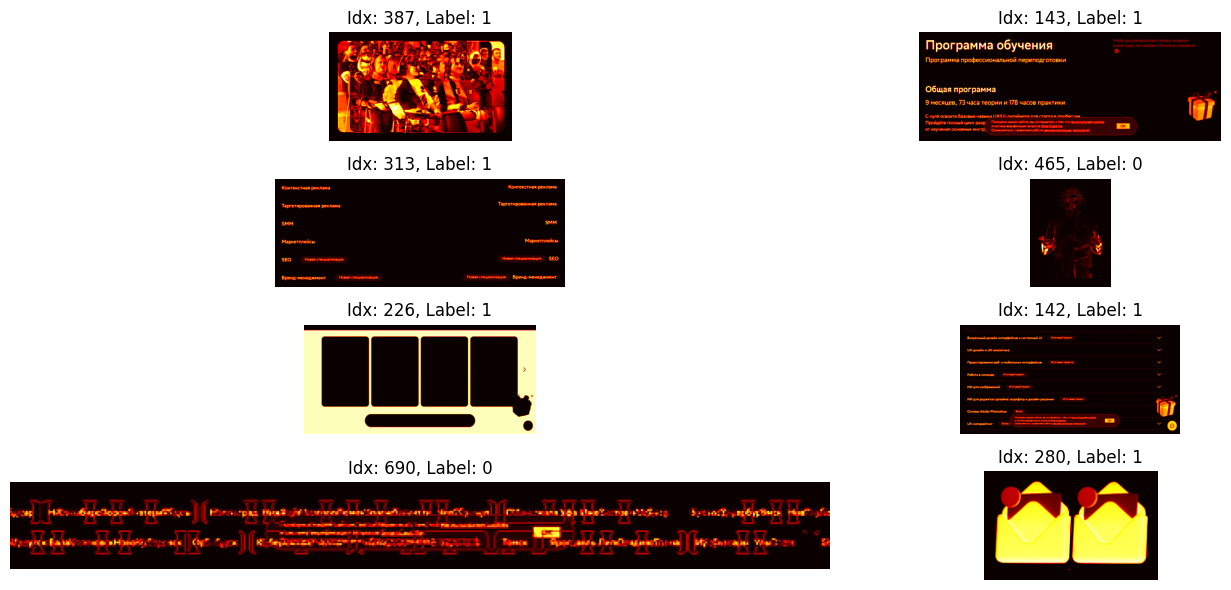

In [43]:
error_indexes = np.where(y_pred != y_test)[0]
incorrect_original_indices = idx_test[error_indexes]
print(f"Индексы с ошибками {incorrect_original_indices}")


fig, axes = plt.subplots(4, 2, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < len(incorrect_original_indices):
        idx = incorrect_original_indices[i]
        if idx < len(X):
            ax.imshow(X[idx], cmap='hot')
            ax.set_title(f'Idx: {idx}, Label: {y[idx]}')
            ax.axis('off')
plt.tight_layout()
plt.show()

 ### Выводы 

#### Было
 Добавлением признаков не получается решить пропуск 1 дефекта.
 Так как мы получили очень хорошую оценку сразу, но явно нам не хватает признака, который бы однозначно определял что 197 diff это баг. Конечно можно увеличить количество данных для обучения. Но и дефект является синтетическим. Так что думаю, что на этом можно остановиться для классических моделей.
 Пробовать другие классические модели на таком скромном дата сете смысла не имеет. Но вот очень интересно как с этим справятся нейронные сети! 

#### Стало
 После добавления последних признаков стало даже хуже.
 Видимо 0,97 это один из пределов, для которых нужно будет приложить немало усилий. Сам результат в 0,97 очень хорош и докручивать до 1 можно, но в первую очередь это будет связанно с датасетом, который учебный с ограничениями, что баннеры это проблема, на самом деле их исключить не сложно.
 А вот вывод, что от увеличения датасета в 2 раза мы особо не получили прироста или падения, что наша модель стабильна, очень важен! Да она просела на 1%, но это я в данные уже начал добавлять откровенные сложности.
 
 Проверим модель на кросс валидацию.

In [47]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=69)

subtype_metrics = {st: {'accuracy': []} for st in np.unique(subtype_labels)}

fold_accuracies = []
all_y_true = []
all_y_pred = []

print("=" * 50)
print("РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ")
print("=" * 50)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_features, subtype_labels)):
    X_tr, X_te = X_features.iloc[train_idx], X_features.iloc[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    sub_te = subtype_labels[test_idx]
    
    model = RandomForestClassifier(random_state=69)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    all_y_true.extend(y_te)
    all_y_pred.extend(y_pred)
    
    fold_acc = accuracy_score(y_te, y_pred)
    fold_accuracies.append(fold_acc)
    
    print(f"\nФолд {fold+1}: accuracy = {fold_acc:.4f}")
    
    for subtype in np.unique(sub_te):
        mask = (sub_te == subtype)
        if mask.sum() > 0:
            st_acc = accuracy_score(y_te[mask], y_pred[mask])
            subtype_metrics[subtype]['accuracy'].append(st_acc)

print("\n" + "=" * 50)
print("ИТОГОВЫЕ МЕТРИКИ")
print("=" * 50)

print(f"\nСредняя accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"95% ДИ: {np.mean(fold_accuracies) - 1.96*np.std(fold_accuracies):.4f} - "
      f"{np.mean(fold_accuracies) + 1.96*np.std(fold_accuracies):.4f}")

print("\nAccuracy по подтипам:")
print("-" * 40)
for subtype in np.unique(subtype_labels):
    accs = subtype_metrics[subtype]['accuracy']
    print(f"{subtype:15s}: {np.mean(accs):.4f} ± {np.std(accs):.4f}  (по {len(accs)} фолдам)")

print("\nОбщий classification report:")
print("-" * 40)
print(classification_report(all_y_true, all_y_pred, target_names=['Not Bug', 'Bug']))

РЕЗУЛЬТАТЫ КРОСС-ВАЛИДАЦИИ

Фолд 1: accuracy = 0.9878

Фолд 2: accuracy = 0.9939

Фолд 3: accuracy = 0.9756

Фолд 4: accuracy = 0.9816

Фолд 5: accuracy = 0.9877

ИТОГОВЫЕ МЕТРИКИ

Средняя accuracy: 0.9853 ± 0.0062
95% ДИ: 0.9731 - 0.9975

Accuracy по подтипам:
----------------------------------------
banner         : 0.9937 ± 0.0077  (по 5 фолдам)
color_change   : 0.9800 ± 0.0400  (по 5 фолдам)
disappeared    : 0.9800 ± 0.0187  (по 5 фолдам)
dynamic        : 0.9900 ± 0.0200  (по 5 фолдам)
shift          : 0.9733 ± 0.0249  (по 5 фолдам)

Общий classification report:
----------------------------------------
              precision    recall  f1-score   support

     Not Bug       0.98      0.99      0.99       418
         Bug       0.99      0.98      0.98       400

    accuracy                           0.99       818
   macro avg       0.99      0.99      0.99       818
weighted avg       0.99      0.99      0.99       818



### Выводы
Кросс-валидация говорит о стабильности модели.
0,97 отличный и стабильный результат.
Модель можно использовать для классификации нестабильных скриншотов регрессионной проверки верстки UI!